### WS 2020/21 <span style="float: right;">GET Lab<br />Paderborn University</span><br />
## <center>Digital Image Processing I<br /><br />Task Sheet 4</center>
---

### Overview

The main objective of this exercise is to study gray-level transformation functions. Such functions are mainly used for image enhancement, for example, to highlight specific image regions or to enhance the contrast. The following figure shows a subset of the most common transformation functions:

<br />
<center><img src="images/transformations.png" width="800px" /></center>

---

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

dpi = plt.rcParams['figure.dpi']

# plot grayscale image in original size
def plot_img_orig(img):
    rows, cols = img.shape # image size
    fig = plt.figure(figsize = (cols/dpi, rows/dpi))
    fig.add_axes([0, 0, 1, 1])
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.show()

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.1</span> Thresholding

One application of thresholding is segmentation (finding specific image regions for further processing). In this example, the task is to segment numbers, which can then be evaluated using optical character recognition (OCR) or other algorithms. 

Implement the following tasks:
1. Read an image (numbers.png from the folder *images*) as a grayscale image and plot it.
2. Determine the minimum gray value of the numbers (the background is black and all numbers have a gray value $> 0$).
3. Apply thresholding to the image to segment all numbers and plot the result.

*Note*: A helpful function from Numpy which can be used here is <a href="https://numpy.org/doc/stable/reference/generated/numpy.nonzero.html">`nonzero` ↗</a>. The corresponding OpenCV function (not to be used here) is <a href="https://docs.opencv.org/4.2.0/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57">`threshold` ↗</a>.

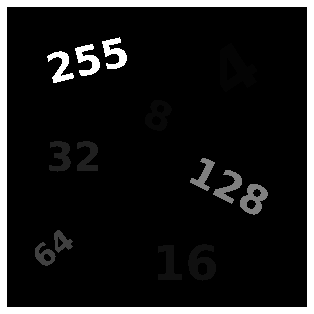

In [2]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/numbers.png', 0)
plot_img_orig(img)

In [3]:
# get and print the minimum gray value of the numbers
min = np.amin(img[np.nonzero(img)]) # nonzero returns the indices of non-zero elements
print("min = " + str(min))

min = 4


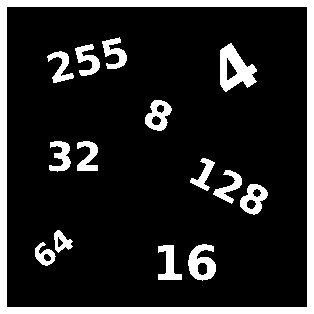

In [4]:
# apply thresholding (set pixel 255 if value >= min) and plot the result
# for loops can be used as an alternative.
indices = np.nonzero(img >= min)
img[indices] = 255
plot_img_orig(img)


The numbers are successfully segmented and even the small numbers with low grey values become visible.

#### <span style="color: RoyalBlue; font-weight: bold;">Task 4.2</span> Negative Image

One application of negative images is printing on white paper. If the image structures of interest are on a dark background, mainly these structures are printed when using the negative image. In this example, an image of the Spitzer telescope is considered.

Implement the following tasks:
1. Read an image (galaxy-ic-342.jpg from the folder *images*) as a grayscale image and plot it.
2. Compute the corresponding negative image and plot the result.

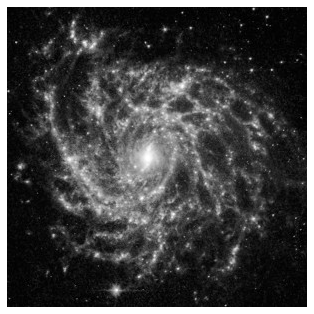

In [5]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/galaxy-ic-342.jpg', 0)
plot_img_orig(img)

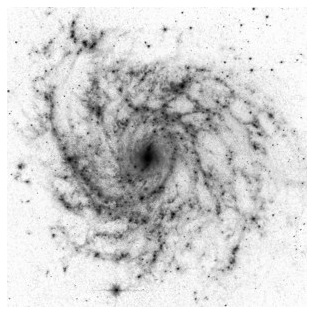

In [6]:
# compute and plot the negative image
img = 255-img
plot_img_orig(img)

### <span style="color: RoyalBlue; font-weight: bold;">Task 4.3</span> Gray-level Slicing

Gray-level slicing can be used to highlight specific image parts. In this example, the goal is to highlight the cells in an image while keeping the other gray values unchanged.

Implement the following tasks:
1. Write a function to apply gray-level slicing in the interval $[a, b]$.
2. Read an image (cells.png from the folder *images*) as a grayscale image and plot it.
3. Transform the image so that the cells become clearly visible and plot the result.

In [7]:
# set gray values from [a,b] to grayval
def slice_gray_levels(img, a, b, grayval):
    rows, cols = img.shape # image size
    
    for iy in range(rows):
        for jx in range(cols):
            if (img[iy, jx] >= a) and (img[iy, jx] <= b):
                img[iy, jx] = grayval

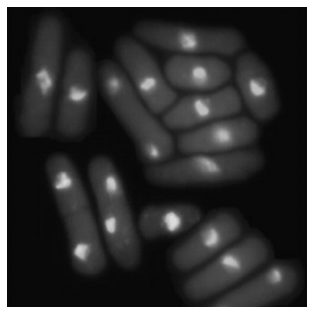

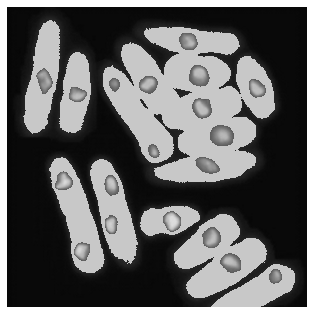

In [8]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/cells.png', 0)
plot_img_orig(img)

# transformation
slice_gray_levels(img, 40, 90, 200)
plot_img_orig(img)

The cells become clearly visible without affecting the cell kernels.

### <span style="color: RoyalBlue; font-weight: bold;">Task 4.4</span> Range Scaling

Sometimes images have (gray) values in a specific range $[a, b]$ and should be mapped to the standard range $[0, 255]$. Some devices for image formation or certain image processing algorithms (e.g., Fourier transform) even produce values outside this range. In such cases, the goal is the following mapping (range scaling): $[a, b] \rightarrow [0, 255]$.

Implement / solve the following tasks:
1. Derive the transformation function for this mapping.
2. Write a function to map the gray values of an image according to $[a, b] \rightarrow [0, 255]$.
3. Read an image (gull.png from the folder *images*) as a grayscale image and plot it.
4. Map the gray values in this image to $[0, 255]$ and plot the result.

The transformation function can be determined based on the mathematical function of a straight line and is given as follows:
    
$$T(r) = 255 \dfrac{r-a}{b-a}$$

In [9]:
# write your code here
# Let an image has gray levels[20,70], it might look darker and the details...
# are in smaller range. we want to spread it from 0 to 255, [0,255], so that the image 
# will have better distribution of pixels for greater details.
# map gray values from [a,b] -> [0,255]
def map_gray_values(img, a, b):
    rows, cols = img.shape # image size
    
    for iy in range(rows):
        for jx in range(cols):
            if (b-a) > 0:
                img[iy, jx] = 255 * (img[iy, jx] - a)/(b-a) #T(r)=(r-a)/(b-a), formula for range slicing.
            else:
                print("Interval out of bounds.")

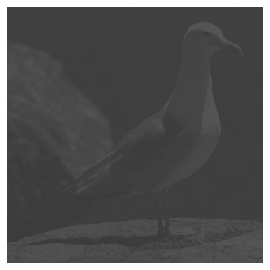

In [10]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/gull.png', 0)
plot_img_orig(img)

min = 60, max = 84


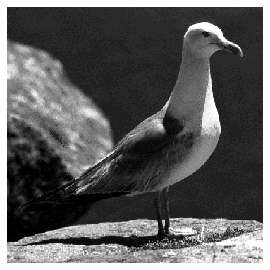

In [11]:
# map the gray values using map_gray_values() function
min = np.amin(img)
max = np.amax(img)
print("min = " + str(min) + ", max = " + str(max))

map_gray_values(img, min, max)
plot_img_orig(img)

In [12]:
np.amin(img), np.amax(img)

(0, 255)

### <span style="color: RoyalBlue; font-weight: bold;">Task 4.5</span> Log Transformation

The log transformation is particularly useful for contrast enhancement, as it expands the values of the dark pixels while compressing the higher level values. In this example, the magnitude of the Fourier spectrum of an image (lena.jpg) is considered. 

Implement the following tasks:
1. Write a function to apply a log transformation to an image.
2. Read an image (spectrum-lena.png from the folder *images*) as a grayscale image and plot it.
3. Transform the image and plot the result.

In [13]:
# apply log transformation
def log_transformation(img):
    rows, cols = img.shape # image size
    c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
    print('Constant c is: ',c)
    for iy in range(rows):
        for jx in range(cols):
            c = 255 / np.log(1 + np.amax(img)) # normalize result to 255*[0,1]
            img[iy, jx] = c * np.log(1 + img[iy, jx]) # min of log = 0, max = np.log(1 + img[i, j])
#what was the reason for calculating c inside for-loop?

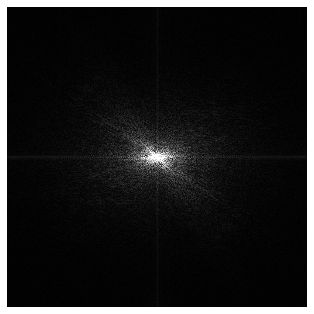

In [14]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/spectrum-lena.png', 0)
plot_img_orig(img)

Constant c is:  45.98590442833571


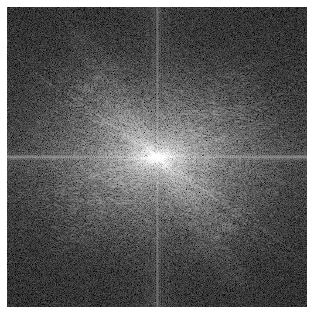

In [15]:
# transformation
log_transformation(img)
plot_img_orig(img)

### <span style="color: RoyalBlue; font-weight: bold;">Task 4.6</span> Gamma Correction

As various devices, e.g., frame grabbers, printers and displays respond according to a power law (instead of linear to the intensity or gray values), gamma correction is often used to correct these phenomena.

Implement the following tasks:
1. Write a function to apply a gamma correction to an image.
2. Create an image with 256 $\times$ 256 pixels and an intensity ramp from left to right.
3. Transform the image to simulate how it is displayed on a monitor with $\gamma = 2$.
4. Transform the simulation image so that it is displayed correctly again.
5. Plot and compare the images.

*Note*: A helpful function from Numpy which can be used here is <a href="https://numpy.org/doc/stable/reference/generated/numpy.arange.html">`arange` ↗</a>.

In [16]:
# apply gamma correction
def gamma_correction(img, gamma, c=255):
    rows, cols = img.shape # image size
    
    for iy in range(rows):
        for jx in range(cols):
            img[iy, jx] = 255 * ((img[iy, jx] / 255) ** gamma) 

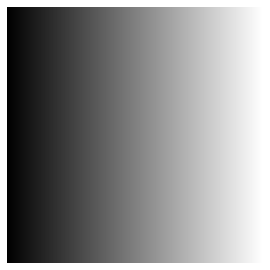

In [17]:
# create image with intensity ramp
img = np.zeros(shape=(256,256), dtype=np.uint8)
img[:,:] = np.arange(0, 256, 1) # creates [0, 1, 2, ..., 255], last value (256) not included

# plot the original image
plot_img_orig(img)

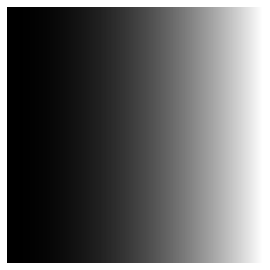

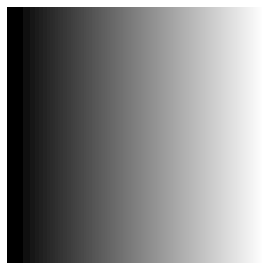

In [18]:
# transformation (simulate monitor)
gamma_correction(img, 2.0)
plot_img_orig(img)

# gamma correction
gamma_correction(img, 0.5)
plot_img_orig(img)

Besides some small artifacts (due to the rounding of the values of the gamma correction to integer) the image is displayed correctly again. 

### <span style="color: RoyalBlue; font-weight: bold;">Task 4.7</span> Bit-plane slicing

Bit-plane slicing can be used to highlight the contribution of specific bits to an image. By this means, the relative importance of each bit for the appearance of an image can be analyzed. An application example is image compression, where unimportant bits can be left out.

Implement the following tasks:
1. Read an image (10-euro.png from the folder *images*) as a grayscale image and plot it.
2. Compute the bit-planes and plot the results.
3. Determine the gray value of the lettering "SPECIMEN".

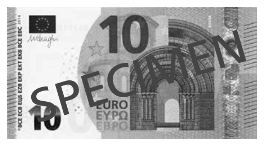

In [19]:
# read the image as a grayscale image (parameter 0)
img = cv2.imread('images/10-euro.png', 0)
plot_img_orig(img)

In [20]:
# create image with ones (binary 00000001)
img_ones = np.ones(shape=img.shape, dtype=np.uint8)
img_ones

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], dtype=uint8)

In [21]:
# create the bit-planes by bit shifting (bit of interest is on the right)
# shifting by 0 bits only given for the sake of clarity
plane_0 = 255 * cv2.bitwise_and(img >> 0, img_ones);
cv2.imwrite('output/plane_0.png', plane_0)
plane_0

array([[  0,   0, 255, ..., 255, 255,   0],
       [  0, 255, 255, ..., 255, 255,   0],
       [  0, 255, 255, ..., 255,   0, 255],
       ...,
       [255,   0, 255, ...,   0, 255, 255],
       [  0,   0,   0, ..., 255,   0,   0],
       [  0, 255,   0, ..., 255,   0, 255]], dtype=uint8)

In [22]:
plane_1 = 255 * cv2.bitwise_and(img >> 1, img_ones);
cv2.imwrite('output/plane_1.png', plane_1)
plane_1

array([[  0, 255, 255, ...,   0, 255,   0],
       [  0, 255, 255, ...,   0,   0, 255],
       [  0,   0, 255, ...,   0,   0,   0],
       ...,
       [  0, 255,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0, 255,   0],
       [255,   0,   0, ...,   0,   0, 255]], dtype=uint8)

In [28]:
img

array([[160, 170, 187, ..., 185, 179, 184],
       [164, 167, 171, ..., 169, 169, 174],
       [184, 185, 151, ..., 173, 168, 165],
       ...,
       [177, 170, 157, ..., 164, 161, 157],
       [168, 164, 156, ..., 169, 166, 160],
       [186, 181, 164, ..., 165, 160, 159]], dtype=uint8)

In [49]:
img >> 1

array([[80, 85, 93, ..., 92, 89, 92],
       [82, 83, 85, ..., 84, 84, 87],
       [92, 92, 75, ..., 86, 84, 82],
       ...,
       [88, 85, 78, ..., 82, 80, 78],
       [84, 82, 78, ..., 84, 83, 80],
       [93, 90, 82, ..., 82, 80, 79]], dtype=uint8)

In [26]:
cv2.bitwise_and(img >> 1, img_ones)

array([[0, 1, 1, ..., 0, 1, 0],
       [0, 1, 1, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [1, 0, 0, ..., 0, 0, 1]], dtype=uint8)

In [23]:
plane_2 = 255 * cv2.bitwise_and(img >> 2, img_ones); 
cv2.imwrite('output/plane_2.png', plane_2)
plane_2

array([[  0,   0,   0, ...,   0,   0,   0],
       [255, 255,   0, ...,   0,   0, 255],
       [  0,   0, 255, ..., 255,   0, 255],
       ...,
       [  0,   0, 255, ..., 255,   0, 255],
       [  0, 255, 255, ...,   0, 255,   0],
       [  0, 255, 255, ..., 255,   0, 255]], dtype=uint8)

In [24]:
plane_3 = 255 * cv2.bitwise_and(img >> 3, img_ones); 
cv2.imwrite('output/plane_3.png', plane_3)
plane_4 = 255 * cv2.bitwise_and(img >> 4, img_ones); 
cv2.imwrite('output/plane_4.png', plane_4)
plane_5 = 255 * cv2.bitwise_and(img >> 5, img_ones); 
cv2.imwrite('output/plane_5.png', plane_5)
plane_6 = 255 * cv2.bitwise_and(img >> 6, img_ones); 
cv2.imwrite('output/plane_6.png', plane_6)
plane_7 = 255 * cv2.bitwise_and(img >> 7, img_ones); 
cv2.imwrite('output/plane_7.png', plane_7)

#plot_img_orig(plane_0)
# Results are saved as images and displayed using HTML

True

<img src="output/plane_0.png"> <img src="output/plane_1.png"> <img src="output/plane_2.png"> <img src="output/plane_3.png"><br />
<img src="output/plane_4.png"> <img src="output/plane_5.png"> <img src="output/plane_6.png"> <img src="output/plane_7.png"><br />

The lettering "SPECIMEN" appears white in the bitplanes 0, 2 and 6. The corresponding binary and gray value is therefore: $01000101 = 96$.

In [1]:
#https://realpython.com/python-bitwise-operators/
#understanding bit-shift operators